In [46]:
%matplotlib inline

import random
import torch
from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt

In [47]:
# 使用 w = [2, -3.4], b = 4.2 和噪声eps噪声项生成数据
# eps 服从均值为0的正态分布

def synthetic_data(w, b, num_example):
    """生成y = xw + b + noise"""
    X = torch.normal(0, 1, (num_example, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

In [48]:
true_w = torch.tensor([2, -3.4])
true_b = torch.tensor(4.2)
features, labels = synthetic_data(true_w, true_b, 1000)
features, labels

(tensor([[-1.2550,  0.8238],
         [ 0.5847, -1.5881],
         [-0.0368, -0.2189],
         ...,
         [-0.5427,  0.1290],
         [-1.0986,  1.8784],
         [-0.8351, -0.7502]]),
 tensor([[-1.1097],
         [10.7706],
         [ 4.8844],
         [ 1.3181],
         [ 2.4262],
         [ 6.2765],
         [ 7.3449],
         [ 7.7253],
         [ 7.5671],
         [ 2.2622],
         [11.4194],
         [ 1.8457],
         [ 4.0141],
         [-2.5741],
         [ 3.7018],
         [ 3.2916],
         [ 8.8362],
         [ 5.4799],
         [ 7.6295],
         [ 6.6927],
         [ 4.6289],
         [ 4.4549],
         [-0.2361],
         [ 5.8819],
         [ 0.7469],
         [ 4.6573],
         [ 2.3392],
         [ 2.5897],
         [11.9050],
         [ 4.6220],
         [10.8087],
         [ 2.8489],
         [ 2.7243],
         [ 1.3648],
         [ 7.9498],
         [ 0.4268],
         [ 4.1531],
         [ 0.4679],
         [ 6.9313],
         [-0.0278],
         [

In [49]:
print(f"features: {features[0]}, label: {labels[0]}")
print(features.shape, labels.shape)

features: tensor([-1.2550,  0.8238]), label: tensor([-1.1097])
torch.Size([1000, 2]) torch.Size([1000, 1])


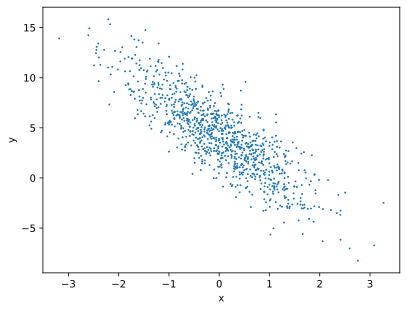

In [50]:
# 绘制 features与labels之间的关系
fig, ax = plt.subplots()
backend_inline.set_matplotlib_formats('svg')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), s=1)
plt.show()


In [51]:
# 读取数据集
def data_iter(batch_size, features, labels):
    """
    yeild 关键词返回一个generator, 
    它是一个generator对象，可以用next(gen_obj)
    访问下一批数据, 或者用for循环遍历访问
    """
    num_examples = len(features)
    indices = list(range(num_examples)) # index的复数
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]
        # 一个torch张量A, 可以A[torch.tensor(\*\*\*)]这样提取元素吗？
        # 可以，而且这是 PyTorch 里非常重要的一种操作，叫 advanced indexing（高级索引）。
        # 甚至可以放入一个 bool tensor


In [52]:
for X, y in data_iter(10, features, labels):
    print(X, y, sep='\n')

tensor([[-0.0368, -0.2189],
        [ 0.6376,  0.1207],
        [ 0.4292, -0.3525],
        [-1.7821, -1.0319],
        [-0.9173,  0.3082],
        [-1.4361,  0.4093],
        [ 0.4352,  0.3034],
        [ 0.1244,  0.6788],
        [ 2.0185, -1.7452],
        [ 0.1313, -0.6248]])
tensor([[ 4.8844],
        [ 5.0678],
        [ 6.2714],
        [ 4.1480],
        [ 1.3181],
        [-0.0656],
        [ 4.0236],
        [ 2.1470],
        [14.1591],
        [ 6.5922]])
tensor([[ 8.9420e-01, -1.7400e+00],
        [ 1.1881e+00,  2.9907e-01],
        [-1.9396e+00, -7.3953e-01],
        [ 3.0244e-02,  6.8991e-01],
        [-2.9345e-02, -3.3529e-01],
        [-6.4248e-01,  4.5392e-01],
        [-1.9878e-01,  1.3315e-03],
        [-3.4700e-01,  1.1774e+00],
        [-4.8867e-01, -3.0262e-01],
        [ 4.1431e-01,  5.9164e-01]])
tensor([[11.9133],
        [ 5.5542],
        [ 2.8324],
        [ 1.9344],
        [ 5.2932],
        [ 1.3700],
        [ 3.7768],
        [-0.4978],
        [ 4.258

In [53]:
# 初始化模型参数

w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)
w, b

(tensor([[-0.0106],
         [ 0.0029]], requires_grad=True),
 tensor([0.], requires_grad=True))

In [54]:
# 定义模型 
def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b

In [55]:
# 定义损失函数
def squared_loss(y_hat, y):
    """均方损失"""
    # return (y_hat - y) ** 2 / 2
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2


In [56]:
def sgd(params, lr, batch_size):
    """
    小批量随机梯度下降, 
    Stochastic gradient descent
    """

    with torch.no_grad(): # 这里不会构建计算图
        # with 关键字表明代码块执行完成后释放资源
        for params in params:
            params -= lr * params.grad / batch_size
            params.grad.zero_()

In [57]:
lr = 0.01
num_epochs = 10
batch_size = 10
net = linreg
loss = squared_loss
loss_list = []
# 模型参数
# w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
# b = torch.zeros(1, requires_grad=True)
# 模型参数, 初始化为0会怎么样？
# w = torch.zeros((2, 1), requires_grad=True)
# b = torch.zeros(1, requires_grad=True)
w, b

(tensor([[-0.0106],
         [ 0.0029]], requires_grad=True),
 tensor([0.], requires_grad=True))

In [58]:
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        # print(X, y, sep='\n')
        l = loss(net(X, w, b), y)
        l.sum().backward()
        loss_list.append(l.detach().mean()) 
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f"epoch {epoch + 1}, loss {train_l.mean().float()}")

epoch 1, loss 2.3004369735717773
epoch 2, loss 0.33387449383735657
epoch 3, loss 0.049104899168014526
epoch 4, loss 0.007341715041548014
epoch 5, loss 0.001144454930908978
epoch 6, loss 0.00021432788344100118
epoch 7, loss 7.284751336555928e-05
epoch 8, loss 5.1264487410662696e-05
epoch 9, loss 4.807899676961824e-05
epoch 10, loss 4.7534602344967425e-05


In [59]:
# 参数与真值的误差
print(f"w的误差：{true_w - w.reshape(true_w.shape)}")
print(f"b的误差：{true_b - b}")

w的误差：tensor([ 0.0005, -0.0007], grad_fn=<SubBackward0>)
b的误差：tensor([0.0002], grad_fn=<SubBackward0>)


1000 1000


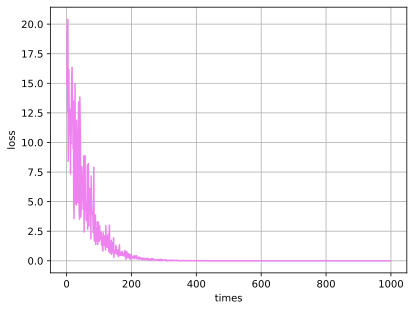

In [64]:
loss_list
times = [i for i in range(num_epochs * int(len(features) / batch_size))]
print(len(loss_list), len(times))
fig, ax = plt.subplots()
ax.set_xlabel("times")
ax.set_ylabel("loss")
# ax.set_xscale("log")
ax.grid()
ax.plot(times, loss_list, c='violet')
plt.show()